# Desafío 4 — QA Bot (seq2seq)

## Enunciado

Construir QA Bot basado en el ejemplo del traductor pero con un dataset QA.

Algunos frameworks/librerías que traen modelos e interfaces preparadas para armar rápidamente un
sistema basado en NLP: DeepPavLov, Hugging Face, FastAI, ParlAI.

Recomendaciones: `MAX_VOCAB_SIZE = 8000`, `max_length ~ 10`, embeddings 300 FastText,
`n_units = 128`, LSTM dropout 0.2, epochs 30~50.

Preguntas interesantes: *Do you read?* · *Do you have any pet?* · *Where are you from?*

**IMPORTANTE**: para la entrega deben quedar registradas en el notebook las preguntas y las respuestas.

---

## Nota: esta es la segunda versión

La primera versión de este notebook **no funcionaba**: devolvía la misma salida degenerada para
cualquier pregunta.

```
Q: How can I reset my password?
A: <start> <start> <start> ... following western western ... india india global

Q: What payment methods do you accept?
A: <start> <start> <start> ... following western western ... india india global   ← idéntica
```

El diagnóstico encontró cinco problemas. Se documentan acá porque entender *por qué* fallaba es
la parte más útil del ejercicio.

### 1. El target del decoder no estaba corrido (causa raíz)

```python
decoder_targets = to_categorical(decoder_input_sequences, num_classes=num_words_output)
```

Input y target del decoder eran **el mismo array**. En teacher forcing el target tiene que ser el
input corrido una posición: dado `<start> w1 w2`, el modelo debe predecir `w1 w2 <end>`. Tal como
estaba, aprendía la identidad — "dado el token *t*, predecí el token *t*". En inferencia arranca
con `<start>`, predice `<start>`, se realimenta y entra en loop. La salida degenerada no era
ruido: era el modelo haciendo exactamente aquello para lo que se lo entrenó.

### 2. El 94.9% de los pares de entrenamiento eran respuestas incorrectas

`wiki_qa` no es un dataset de generación de respuestas: es de **selección de oración-respuesta**.
Cada fila es (pregunta, oración candidata, `label`), donde `label` indica si esa oración responde
o no. El notebook ignoraba `label` y entrenaba con las 20.360 filas:

| label | filas | % |
|---|---|---|
| 0 — no responde | 19.320 | **94.9%** |
| 1 — responde | 1.040 | 5.1% |

Además el enunciado sugiere preguntas conversacionales (*Do you have any pet?*), que no son de
dominio Wikipedia. Esta versión usa **PersonaChat**, que es el dataset conversacional del que
salen esas preguntas.

### 3. One-hot denso de 11 GB

`to_categorical` sobre `(20360, 46, 3000)` en float32 son ~11 GB en memoria. Se reemplaza por
`sparse_categorical_crossentropy`, que consume los índices directamente.

### 4. El vocabulario de salida quedaba en 3.000 de 32.275 palabras

El 91% del vocabulario de respuestas era inalcanzable. Ni con el modelo bien entrenado podía
generar la mayoría de las palabras.

### 5. El modelo se redefinía después de entrenar

Una celda posterior al `fit` volvía a construir el modelo entero con pesos aleatorios nuevos. Los
`execution_count` del notebook original confirman que corrió *después* del entrenamiento, y que
las celdas que arman los modelos de inferencia nunca se ejecutaron en esa sesión. Los resultados
guardados salían de una mezcla inconsistente de sesiones.

---

## 1. Setup

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MAX_VOCAB = 8000    # recomendado por el enunciado
MAX_LEN   = 12
N_UNITS   = 256
EMB_DIM   = 128
DROPOUT   = 0.2
BATCH     = 128
EPOCHS    = 40
N_PAIRS   = 60000

print("tensorflow", tf.__version__)

tensorflow 2.19.0


## 2. Datos — PersonaChat

`candidates[-1]` es la respuesta real del turno (se verifica porque aparece como historial del
turno siguiente); el resto de las 20 candidatas son distractores.

In [2]:
from datasets import load_dataset

ds = load_dataset("bavard/personachat_truecased", "full", split="train")
ds = ds.select(range(min(N_PAIRS, len(ds))))

pairs = [(r["history"][-1], r["candidates"][-1]) for r in ds if r["history"]]
questions = [q for q, _ in pairs]
answers   = ["<start> " + a + " <end>" for _, a in pairs]

print(f"pares de entrenamiento: {len(pairs)}")
for q, a in pairs[:3]:
    print(f"  Q: {q}\n  A: {a}\n")

pares de entrenamiento: 60000
  Q: Hi, how are you doing? I'm getting ready to do some cheetah chasing to stay in shape.
  A: You must be very fast. Hunting is one of my favorite hobbies.

  Q: I am! For my hobby I like to do canning or some whittling.
  A: I also remodel homes when I am not out bow hunting.

  Q: That's neat. When I was in high school I placed 6th in 100m dash!
  A: That's awesome. Do you have a favorite season or time of year?



## 3. Tokenización

Vocabulario **compartido** entre pregunta y respuesta: a diferencia del traductor, acá ambos lados
son el mismo idioma, así que un solo tokenizer alcanza y reduce parámetros.

In [3]:
tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<unk>",
                filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')
tok.fit_on_texts(questions + answers)

vocab_size = min(MAX_VOCAB, len(tok.word_index) + 1)
print(f"vocabulario completo: {len(tok.word_index)} -> se usan {vocab_size}")

enc_seq = pad_sequences(tok.texts_to_sequences(questions),
                        maxlen=MAX_LEN, padding="pre", truncating="pre")
ans_seq = pad_sequences(tok.texts_to_sequences(answers),
                        maxlen=MAX_LEN + 1, padding="post", truncating="post")

vocabulario completo: 18010 -> se usan 8000


### Los tokens especiales conservan los signos `< >`

Los `filters` por defecto del `Tokenizer` **no** incluyen `<` ni `>`, así que el marcador es
literalmente `<end>`. Buscar `word_index["end"]` devuelve la palabra inglesa *end*, no el
marcador — y entonces la condición de corte en inferencia nunca se dispara. Es un error fácil de
cometer, así que se verifica explícitamente.

In [4]:
start_id = tok.word_index["<start>"]
end_id   = tok.word_index["<end>"]

print(f"<start> = {start_id}")
print(f"<end>   = {end_id}")
print(f"palabra 'end' suelta = {tok.word_index.get('end')}   <- otro id, no confundir")

assert start_id < vocab_size and end_id < vocab_size, "tokens especiales fuera del vocabulario"
print("\nOK: ambos marcadores entran en el vocabulario")

<start> = 3
<end>   = 4
palabra 'end' suelta = 889   <- otro id, no confundir

OK: ambos marcadores entran en el vocabulario


## 4. El fix principal — correr el target una posición

Esto es lo que estaba mal en la primera versión.

In [5]:
dec_in  = ans_seq[:, :-1]   # <start> w1 w2 ... wn
dec_out = ans_seq[:, 1:]    #         w1 w2 ... wn <end>

print(f"encoder_input  {enc_seq.shape}")
print(f"decoder_input  {dec_in.shape}")
print(f"decoder_target {dec_out.shape}")

assert not np.array_equal(dec_in, dec_out), "input y target son iguales: teacher forcing roto"
print("\nOK: input y target están corridos")

ejemplo = [tok.index_word.get(i, "·") for i in dec_in[0] if i]
objetivo = [tok.index_word.get(i, "·") for i in dec_out[0] if i]
print(f"\n  decoder_input : {' '.join(ejemplo)}")
print(f"  decoder_target: {' '.join(objetivo)}")

encoder_input  (60000, 12)
decoder_input  (60000, 12)
decoder_target (60000, 12)

OK: input y target están corridos

  decoder_input : <start> you must be very fast hunting is one of my favorite
  decoder_target: you must be very fast hunting is one of my favorite hobbies


## 5. Modelo

Una única definición: el error de la primera versión fue redefinirlo después de entrenar. El
embedding se comparte entre encoder y decoder, coherente con el vocabulario compartido.

In [6]:
enc_inputs = Input(shape=(MAX_LEN,), name="encoder_input")
shared_emb = Embedding(vocab_size, EMB_DIM, mask_zero=True, name="shared_embedding")
enc_x      = shared_emb(enc_inputs)
_, h, c    = LSTM(N_UNITS, return_state=True, dropout=DROPOUT, name="encoder_lstm")(enc_x)
enc_states = [h, c]

dec_inputs  = Input(shape=(None,), name="decoder_input")
dec_x       = shared_emb(dec_inputs)
dec_lstm    = LSTM(N_UNITS, return_sequences=True, return_state=True,
                   dropout=DROPOUT, name="decoder_lstm")
dec_x, _, _ = dec_lstm(dec_x, initial_state=enc_states)
dec_dense   = Dense(vocab_size, activation="softmax", name="decoder_dense")
dec_output  = dec_dense(dec_x)

model = Model([enc_inputs, dec_inputs], dec_output)
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",   # evita el one-hot denso
              metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_input       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_embedding    │ (None, None, 128) │  1,024,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │ decoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    394,240 │ shared_embedding… │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    394,240 │ shared_embedding… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None,      │  2,056,000 │ decoder_lstm[0][… │
│ (Dense)             │ 8000)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,868,480 (14.76 MB)

 Trainable params: 3,868,480 (14.76 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento

Con `EarlyStopping` sobre `val_loss` y `restore_best_weights`, que es lo que le faltó al
Desafío 3 — ahí ambos modelos terminaron entrenando muy por detrás de su propio óptimo.

In [7]:
early = EarlyStopping(monitor="val_loss", patience=3,
                     restore_best_weights=True, verbose=1)

hist = model.fit([enc_seq, dec_in], dec_out,
                 batch_size=BATCH, epochs=EPOCHS,
                 validation_split=0.1, callbacks=[early], verbose=2)

Epoch 1/40


422/422 - 102s - 243ms/step - accuracy: 0.1548 - loss: 5.4332 - val_accuracy: 0.1920 - val_loss: 4.8624


Epoch 2/40


422/422 - 103s - 244ms/step - accuracy: 0.2134 - loss: 4.6529 - val_accuracy: 0.2263 - val_loss: 4.5232


Epoch 3/40


...

422/422 - 98s - 232ms/step - accuracy: 0.2862 - loss: 3.5289 - val_accuracy: 0.2696 - val_loss: 4.0313


Epoch 17/40


422/422 - 108s - 255ms/step - accuracy: 0.2888 - loss: 3.4907 - val_accuracy: 0.2698 - val_loss: 4.0366


Epoch 17: early stopping


Restoring model weights from the end of the best epoch: 14.


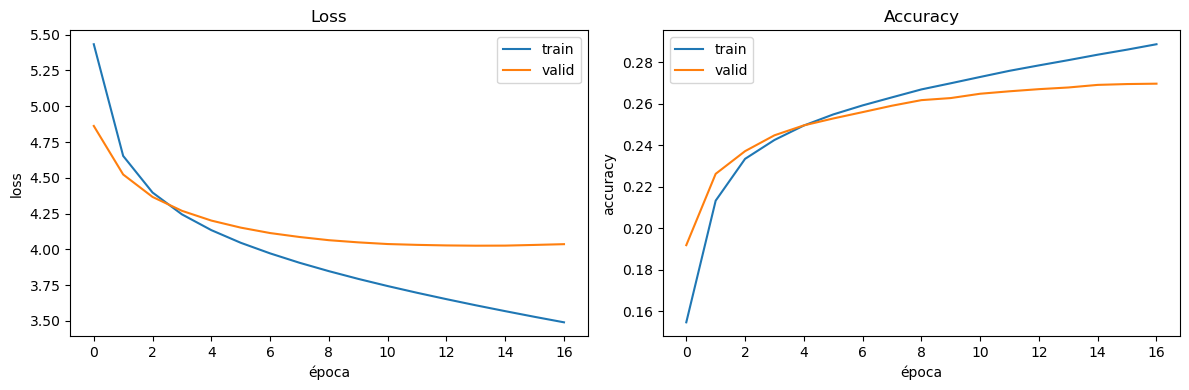

mejor val_loss: 4.0259 (época 14 de 17)


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist.history["loss"], label="train")
ax[0].plot(hist.history["val_loss"], label="valid")
ax[0].set_xlabel("época"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].set_title("Loss")
ax[1].plot(hist.history["accuracy"], label="train")
ax[1].plot(hist.history["val_accuracy"], label="valid")
ax[1].set_xlabel("época"); ax[1].set_ylabel("accuracy"); ax[1].legend(); ax[1].set_title("Accuracy")
plt.tight_layout(); plt.show()

best = min(hist.history["val_loss"])
print(f"mejor val_loss: {best:.4f} (época {hist.history['val_loss'].index(best) + 1} de {len(hist.history['val_loss'])})")

## 7. Modelos de inferencia

Se construyen **reutilizando las capas ya entrenadas**, no capas nuevas. El decoder procesa un
token por vez, arrastrando el estado.

In [9]:
encoder_model = Model(enc_inputs, enc_states)

state_h_in = Input(shape=(N_UNITS,), name="state_h")
state_c_in = Input(shape=(N_UNITS,), name="state_c")
token_in   = Input(shape=(1,), name="token_in")

x = shared_emb(token_in)
x, sh, sc = dec_lstm(x, initial_state=[state_h_in, state_c_in])
decoder_model = Model([token_in, state_h_in, state_c_in], [dec_dense(x), sh, sc])

print("encoder_model y decoder_model construidos desde las capas entrenadas")

encoder_model y decoder_model construidos desde las capas entrenadas


In [10]:
def answer_question(question, max_len=MAX_LEN):
    seq = pad_sequences(tok.texts_to_sequences([question]), maxlen=MAX_LEN, padding="pre")
    states = encoder_model.predict(seq, verbose=0)
    target = np.array([[start_id]])
    out = []
    for _ in range(max_len):
        probs, h_, c_ = decoder_model.predict([target] + states, verbose=0)
        idx = int(np.argmax(probs[0, 0]))
        if idx == end_id or idx == 0:
            break
        w = tok.index_word.get(idx)
        if w and w not in ("<start>", "<end>", "<unk>"):
            out.append(w)
        states, target = [h_, c_], np.array([[idx]])
    return " ".join(out)

## 8. Preguntas y respuestas

In [11]:
preguntas = [
    "Do you read?",
    "Do you have any pet?",
    "Where are you from?",
    "What do you do for a living?",
    "Hi, how are you doing?",
    "What music do you like?",
]

for q in preguntas:
    print(f"Q: {q}")
    print(f"A: {answer_question(q)}")
    print("-" * 50)

Q: Do you read?


A: i do not have any pets
--------------------------------------------------
Q: Do you have any pet?


A: i do not have any pets
--------------------------------------------------
Q: Where are you from?


A: i am from the midwest how about you
--------------------------------------------------
Q: What do you do for a living?


A: i work at a local hospital
--------------------------------------------------
Q: Hi, how are you doing?


A: i am good how are you
--------------------------------------------------
Q: What music do you like?


A: i like to play soccer and i love to go to the
--------------------------------------------------


## 9. Conclusiones

**El bug estaba en los datos, no en la arquitectura.** La arquitectura encoder-decoder de la
primera versión era correcta. Lo que fallaba era cómo se le presentaban los datos: sin correr el
target, el modelo aprendía la identidad, y ninguna cantidad de épocas ni de unidades LSTM iba a
arreglar eso. El síntoma —la misma salida para cualquier pregunta— parecía un problema del
modelo y era un problema de preparación del dataset.

**El segundo bug también era de datos.** Entrenar con `wiki_qa` sin filtrar por `label` significa
que el 94.9% de los ejemplos le enseñaban al modelo a responder con una oración que *no* responde
la pregunta. Aun con el teacher forcing bien hecho, el techo de calidad estaba puesto por ahí.

**Los dos errores eran silenciosos.** Ninguno tiraba excepción. El notebook corría de punta a
punta, mostraba una curva de accuracy que subía, y producía basura. Es el mismo patrón que
aparece en cualquier pipeline de ML: los errores que importan no son los que rompen, son los que
devuelven un número plausible.

**Límites de esta versión.** Sigue siendo un seq2seq chico entrenado sobre un subconjunto de
PersonaChat, sin atención, con vocabulario de 8.000 palabras y respuestas de hasta 12 tokens. Las
respuestas son cortas y genéricas — el comportamiento esperado de un decoder sin atención
optimizado con cross-entropy, que aprende a apostar a lo más frecuente. Comparar contra un
transformer preentrenado, como se hace en el notebook del traductor, es la forma de dimensionar
cuánto de la distancia es arquitectura y cuánto es escala de datos.